In [1]:
#install library dependencies
!pip install -qU langchain langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.6 MB/s eta 0:00:00


In [2]:
from langchain_openai import ChatOpenAI #for LLM Service
from typing import Annotated, Literal #for Annotated and Literal data type

from typing_extensions import TypedDict #for TypedDict data type

from langgraph.graph import StateGraph, START, END #For create graph workflow
from langgraph.graph.message import add_messages #for messages operator

In [3]:
# Input API KEY
import getpass
import os

from google.colab import userdata

if not os.environ.get("OPENAI_API_KEY"):
  try:
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
  except:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

In [4]:
#define the LLM
llm = ChatOpenAI(
    model="gpt-4o-mini"
    )

In [5]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    history: list

In [6]:
#define product_agent node
def product_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  products = '''Berikut ini list produk beserta detail keterangannya:
# Celana Panjang Pria
* **Harga:** Rp299.000
* **Deskripsi:** Beragam pilihan celana panjang pria, mulai dari jeans kasual hingga celana bahan formal. Cocok untuk berbagai kesempatan dan gaya.

# Pakaian Wanita
* **Harga:** Rp189.000
* **Deskripsi:** Koleksi pakaian wanita yang stylish dan nyaman, termasuk atasan, blouse, dan dress kasual. Tersedia dalam berbagai model dan warna untuk melengkapi penampilan Anda sehari-hari.

# Jaket
* **Harga:** Rp399.000
* **Deskripsi:** Jaket dengan berbagai model dan bahan, mulai dari jaket denim, bomber, hingga jaket *windbreaker*. Sempurna untuk menambah gaya dan memberikan kehangatan.

# Sepatu
* **Harga:** Rp450.000
* **Deskripsi:** Beragam jenis sepatu untuk pria dan wanita, termasuk *sneakers*, *loafers*, hingga sepatu formal. Desain trendi dengan kenyamanan optimal untuk aktivitas Anda.

# Tas
* **Harga:** Rp250.000
* **Deskripsi:** Pilihan tas fungsional dan modis seperti tas selempang, ransel, atau *tote bag*. Ideal untuk menemani aktivitas harian Anda, dari bekerja hingga bepergian santai.
'''

  prompt = f'''Kamu adalah chatbot yang membantu pelanggan dalam percakapan tentang produk fashion dari "Toko Pakaian Purwadhika".
Jawab pertanyaan dengan ramah dan sopan, serta persuasif dalam menawarkan barang kepada pelanggan. Gunakan chat history untuk membantu menangkap konteks percakapan.
Berikut ini list produk yang dijual oleh Toko Pakaian Purwadhika beserta detail keterangannya:
{products}

chat history: {history}
question: {question}
'''

  response = llm.invoke(prompt)
  return {"messages": [response]}

In [7]:
#define promo agent node
def promo_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  promo = '''Berikut ini list promo beserta detail keterangannya:
* Senin: Discount 50% untuk semua produk!
* Selasa: Gratis ongkir untuk pembelian di atas Rp100.000!
* Rabu: Buy 2 Get 1 Free untuk semua produk!
* Kamis: Gratis ongkir untuk pembelian di atas Rp50.000!
* Jumat: Discount 30% untuk semua produk!
* Sabtu: Gratis ongkir untuk pembelian di atas Rp75.000!
* Minggu: Discount 20% untuk semua produk!
'''

  prompt = f'''Kamu adalah chatbot yang membantu pelanggan dalam percakapan tentang promo yang ditawarkan oleh "Toko Pakaian Purwadhika".
Jawab pertanyaan dengan ramah dan sopan. Gunakan chat history untuk membantu menangkap konteks percakapan.
Berikut ini list promo yang ditawarkan oleh Toko Pakaian Purwadhika beserta detail keterangannya:
{promo}

chat history: {history}
question: {question}
'''

  response = llm.invoke(prompt)
  return {"messages": [response]}

In [8]:
#define basic agent node
def basic_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  prompt = f'''Kamu adalah chatbot "Toko Pakaian Purwadhika" yang akan membantu menjawab pertanyaan pelanggan.
Jawab pertanyaan dengan ramah dan sopan. Gunakan chat history untuk membantu menangkap konteks percakapan.
chat history: {history}
question: {question}
'''
  response = llm.invoke(prompt)
  return {"messages": [response]}

In [9]:
#define filter agent node
def filter_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  prompt = f'''Kamu adalah agent yang ditugaskan untuk mengklasifikasikan pertanyaan pelanggan menjadi tiga kategori yaitu ["product", "promo", "other"]. Kamu hanya bisa memilih antara tiga kategori tersebut.
Gunakan chat history untuk membantu dalam mengklasifikasikan pertanyaan pelanggan. Jawab hanya nama kategorinya saja.
chat history: {history}
question: {question}'''

  response = llm.invoke(prompt)
  return {"messages": [response]}

In [43]:
#define flow classifier
def classify_flow(state: State)->Literal["product_agent", "promo_agent", "basic_agent"]:
  msg = state["messages"][-1].content
  if msg == "product":
    return "product_agent"
  elif msg == "promo":
    return "promo_agent"
  else:
    return "basic_agent"

In [44]:
#create the workflow, connecting all nodes and rule of the flow
workflow = StateGraph(State)

workflow.add_node("filter_agent", filter_agent)
workflow.add_node("product_agent", product_agent)
workflow.add_node("promo_agent", promo_agent)
workflow.add_node("basic_agent", basic_agent)

workflow.add_edge(START, "filter_agent")
workflow.add_conditional_edges("filter_agent", classify_flow)
workflow.add_edge("product_agent", END)
workflow.add_edge("promo_agent", END)
workflow.add_edge("basic_agent", END)

app = workflow.compile()

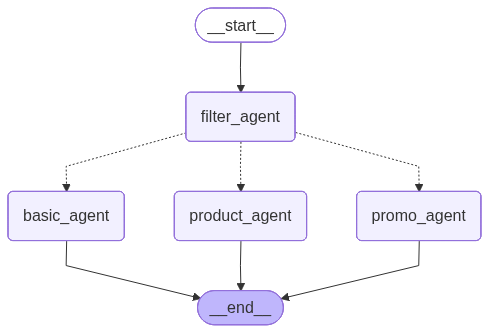

In [45]:
#show the workflow schema
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
#define the state
state_prompt = {
    "messages": [{"role": "user", "content": "produk apa yang cocok dengan pria?"}],
    "history": []
}

In [18]:
#run the agent
agent_response = app.invoke(state_prompt)

In [19]:
agent_response

{'messages': [HumanMessage(content='produk apa yang cocok dengan pria?', additional_kwargs={}, response_metadata={}, id='9af26285-ed40-4db0-9db9-4df42ca8a830'),
  AIMessage(content='product', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 116, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f9565ce549', 'id': 'chatcmpl-DUX7Nxg5hAMJjR3OE6Vz3ozZ4P40Q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d8bf4-0121-76f3-944e-9324e817fc0f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 116, 'output_tokens': 1, 'total_tokens': 117, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_

In [15]:
#check the response
agent_response['messages'][-1].content

'Halo! Untuk pria, kami memiliki beberapa pilihan produk yang sangat cocok. Berikut ini beberapa rekomendasi:\n\n1. **Celana Panjang Pria** - Terdapat beragam pilihan mulai dari jeans kasual hingga celana bahan formal. Harganya hanya Rp299.000 dan cocok untuk berbagai kesempatan, baik santai maupun formal.\n\n2. **Jaket** - Jaket kami tersedia dalam berbagai model seperti jaket denim, bomber, dan windbreaker. Harganya Rp399.000, sangat pas untuk menambah gaya dan memberikan kehangatan.\n\n3. **Sepatu** - Kami juga menawarkan beragam jenis sepatu, mulai dari sneakers hingga sepatu formal, dengan harga Rp450.000. Desainnya trendi dan nyaman untuk aktivitas sehari-hari.\n\nJika ada yang menarik atau jika Anda ingin informasi lebih lanjut tentang produk-produk tersebut, jangan ragu untuk bertanya!'

In [20]:
# run with stream
agent_response = app.stream(state_prompt)
for response in agent_response:
  print(response)

{'filter_agent': {'messages': [AIMessage(content='product', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 119, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a0b064651e', 'id': 'chatcmpl-DUX7hpSRWvR4mwCRb0PCailpRr3vI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d8bf4-500e-7f71-bbef-68a1c1686ba6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 119, 'output_tokens': 1, 'total_tokens': 120, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}
{'product_agent': {'messages': [AIMessage(content='Hai! Terima kasih telah menghubungi T

In [21]:
#use llm with multi-turn interaction
history = []
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        prompt = {
            "messages": [{"role": "user", "content": user_input}],
            "history": history
        }
        answer = app.invoke(prompt)["messages"][-1].content
        print(f"AI: {answer}")
        history.append(f"User: {user_input}")
        history.append(f"AI: {answer}")
        # print(prompt)
    except:
        # fallback if input() is not available
        user_input = "Bad Input"
        print("User: " + user_input)
        break

User: halo apa kabar
AI: Halo! Terima kasih telah menghubungi Toko Pakaian Purwadhika. Saya baik-baik saja, semoga Anda juga dalam keadaan baik. Ada yang bisa saya bantu hari ini?
User: rekomendasikan produk celana laki-laki dong
AI: Tentu! Kami memiliki berbagai pilihan celana panjang pria yang bisa Anda pilih. Mulai dari jeans kasual yang nyaman untuk aktivitas sehari-hari hingga celana bahan formal yang cocok untuk kesempatan lebih resmi. Semua celana ini ditawarkan dengan harga Rp299.000. 

Apakah Anda memiliki preferensi tertentu, seperti model atau warna? Saya bisa membantu Anda menemukan yang paling sesuai!
User: ada promo gak untuk hari ini
AI: Hai! Untuk hari ini, yakni hari Senin, Toko Pakaian Purwadhika sedang menawarkan promo menarik yaitu diskon 50% untuk semua produk! Ini adalah kesempatan yang bagus untuk mendapatkan berbagai item dengan harga yang lebih terjangkau. Apakah Anda tertarik dengan produk tertentu? Saya siap membantu!
User: oik makasi
AI: Sama-sama! Senang bi